In [19]:

import pandas as pd
import numpy as np
# import matplotlib as plt
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
#
# After running train_offshore_models_mvco.py ../config/offshore_surface_layer_training_mvco.yml
# Read in the predictions from the test data
#

# variables needed to make this notebook work for the QC MVCO dataset
directory = 'model_QC_data_Unscale_NN_fix'
predictand1 = 'momentum_flux'
exact_predictand1 = "momentum_flux:18.4_m:m2_s-2"
predictand2 = 'heat_flux'
exact_predictand2 = 'heat_flux:18.4_m:degrees_C_m_s-1' # degrees celsius , meters per second
mo_version = '-mo_branko'
mo_version2 = '-mo_alternate'




pred = pd.read_csv(directory + "/surface_layer_model_predictions.csv")
# pred['Time'] = pd.to_datetime(pred['Time'])
# pred.index = pred['Time'] 

import plotly
import chart_studio.plotly as py
from plotly.graph_objs import Scatter, Layout
import plotly.graph_objs as go
from  plotly.graph_objs import *


In [20]:
pred['Time'] = pd.to_datetime(pred['Time'])


In [ ]:

pred.index = pred['Time'] 

### model metrics


In [10]:
model_metrics = pd.read_csv(directory + '/surface_layer_model_metrics.csv')

In [11]:
model_metrics

,Model,mean_squared_error,mean_absolute_error,mean_error,pearson_r2
0,momentum_flux-random_forest,0.001309,0.022496,0.000640,0.842020
1,momentum_flux-neural_network,0.001491,0.024470,-0.006343,0.828139
2,momentum_flux-mo_branko,0.002592,0.032345,0.002053,0.777145
3,momentum_flux-mo_alternate,0.004342,0.035967,-0.010237,0.774815
4,heat_flux-random_forest,0.000365,0.011456,-0.000398,0.797571
5,heat_flux-neural_network,0.000310,0.010645,-0.000572,0.826822
6,heat_flux-mo_branko,0.001168,0.019748,-0.004377,0.537354
7,heat_flux-mo_alternate,0.002216,0.020861,0.000343,0.506313


### loss function graph for NN

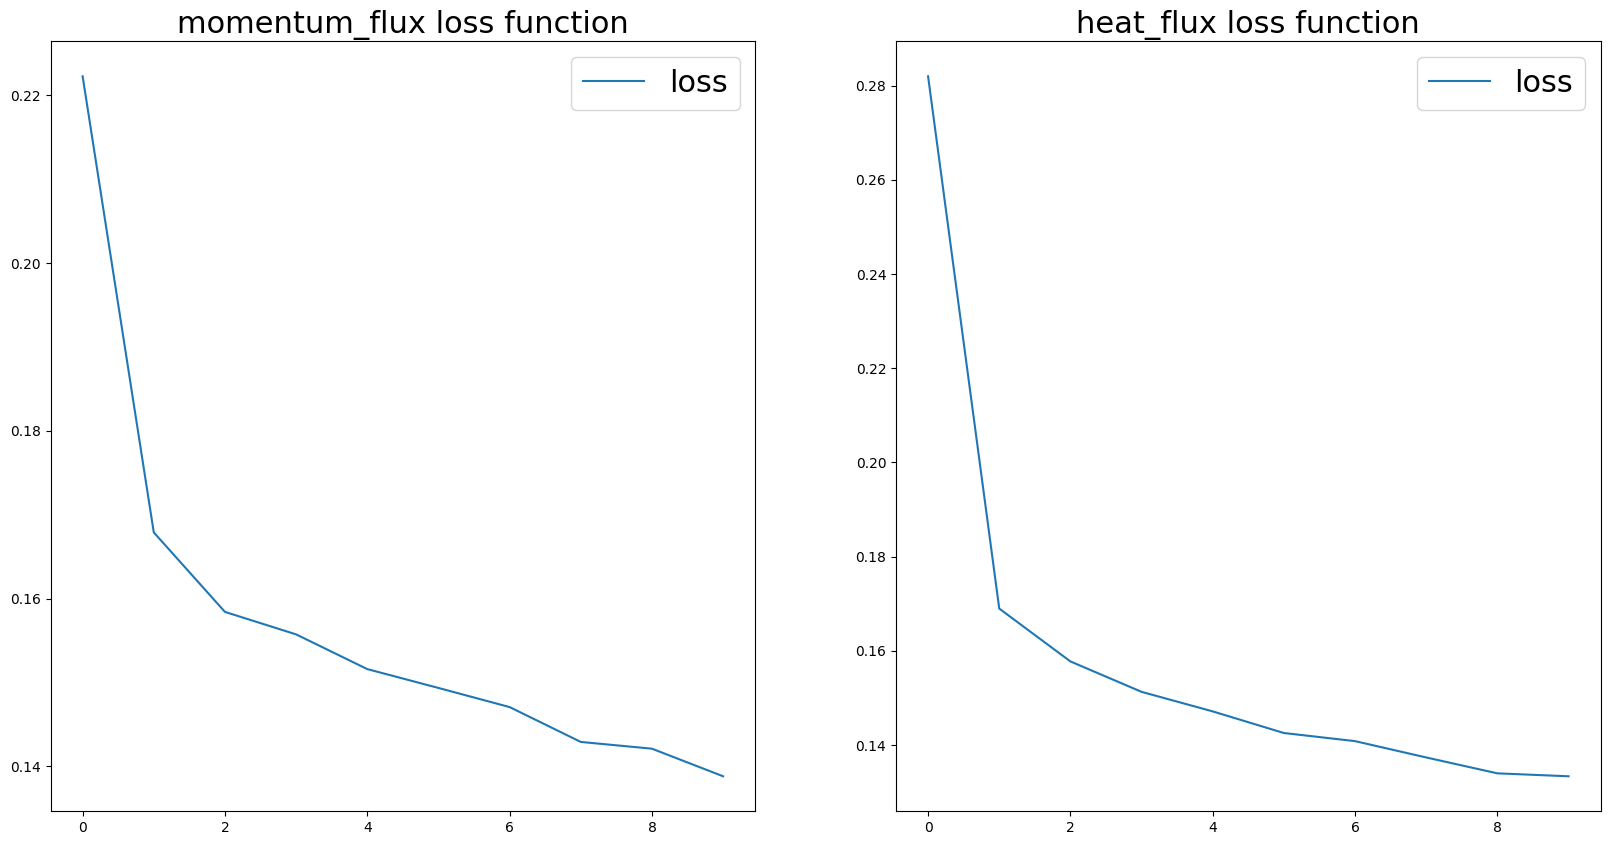

In [12]:
model_types = [predictand1, predictand2]

fig, axs = plt.subplots(1, len(model_types), figsize = (20,10))
ax = axs.flatten()
for i in range(len(ax)):
    df = pd.read_csv(directory + '/' + model_types[i] + '-neural_network_training_history.csv')
    # print(df)
    # ax.plot()

    ax[i].plot(df.index, df['loss'], label='loss')
    # ax[i].plot(df.index, df['val_loss'], label='val_loss')
    ax[i].set_title('{0} loss function'.format(model_types[i]), fontsize=22)
    ax[i].legend(fontsize=22)



plt.show()
    
    


# the rest

In [55]:
pred

,Time,momentum_flux-random_forest,momentum_flux-neural_network,momentum_flux-mo_branko,momentum_flux-mo_alternate,heat_flux-random_forest,heat_flux-neural_network,heat_flux-mo_branko,heat_flux-mo_alternate,temperature:18.4_m:K,...,wind_speed:18.4_m:m_s-1,wind_direction:18.4_m:degrees,angle_between_wind_wave:0_m:degrees,u_wind:18.4_m:m_s-1,v_wind:18.4_m:m_s-1,bulk_richardson:18.4_m:none,u_w:18.4_m:m2_s-2,v_w:18.4_m:m2_s-2,heat_flux:18.4_m:degrees_C_m_s-1,momentum_flux:18.4_m:m2_s-2
Time,,,,,,,,,,,,,,,,,,,,,
2005-07-21 20:00:00,2005-07-21 20:00:00,-0.005420,0.570320,NaN,NaN,-0.003471,-0.356804,NaN,NaN,294.15,...,4.400727,207.02,90.857976,2.00,3.92,0.077714,-0.0127,0.0028,0.00,-0.02
2005-07-21 20:20:00,2005-07-21 20:20:00,-0.006324,0.559472,NaN,NaN,-0.003272,-0.362083,NaN,NaN,294.45,...,5.005317,212.10,90.904074,2.66,4.24,0.066637,-0.0078,-0.0004,0.00,-0.01
2005-07-21 20:40:00,2005-07-21 20:40:00,-0.003667,0.565008,NaN,NaN,-0.003269,-0.358489,NaN,NaN,294.55,...,4.826313,214.43,90.766804,2.73,3.98,0.071387,-0.0043,-0.0006,0.00,-0.01
2005-07-21 21:00:00,2005-07-21 21:00:00,-0.004573,0.580804,NaN,NaN,-0.002726,-0.351065,NaN,NaN,294.05,...,3.862551,200.05,89.994769,1.32,3.63,0.076965,-0.0138,0.0032,0.00,-0.01
2005-07-21 21:20:00,2005-07-21 21:20:00,-0.004710,0.575650,NaN,NaN,-0.002628,-0.352107,NaN,NaN,294.05,...,4.153083,199.74,89.770025,1.40,3.91,0.067666,-0.0144,0.0042,0.00,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-09-10 15:00:00,2015-09-10 15:00:00,-0.013680,0.528416,NaN,NaN,-0.003485,-0.466979,NaN,NaN,295.45,...,5.277973,121.88,89.287278,-4.39,2.93,0.023293,0.0043,0.0047,0.00,0.01
2015-09-10 16:00:00,2015-09-10 16:00:00,-0.013228,0.523315,NaN,NaN,-0.003628,-0.466741,NaN,NaN,295.35,...,5.313690,142.84,89.341156,-3.08,4.33,0.028232,-0.0307,0.0082,-0.02,-0.01
2015-09-10 16:20:00,2015-09-10 16:20:00,-0.010826,0.516192,NaN,NaN,-0.003116,-0.458325,NaN,NaN,295.25,...,4.951040,145.54,88.639119,-3.42,3.58,0.027393,-0.0120,0.0050,-0.02,-0.02


In [57]:
print(len(pred))
print(pred.isna().sum()/len(pred))

15276
Time                                        0.000000
momentum_flux-random_forest                 0.000000
momentum_flux-neural_network                0.000000
momentum_flux-mo_branko                     0.272454
momentum_flux-mo_alternate                  0.272912
heat_flux-random_forest                     0.000000
heat_flux-neural_network                    0.000000
heat_flux-mo_branko                         0.272454
heat_flux-mo_alternate                      0.272912
temperature:18.4_m:K                        0.000000
water_sfc_temperature:0_m:K                 0.000000
pressure:18.4_m:hPa                         0.000000
potential_temperature:18.4_m:K              0.000000
skin_virtual_potential_temperature:0_m:K    0.000000
mixing_ratio:0_m:g_kg-1                     0.000000
mixing_ratio:18.4_m:g_kg-1                  0.000000
relative_humidity:18.4_m:%                  0.000000
wave_direction:0_m:degrees                  0.000000
wave_height:0_m:m                       

In [56]:

#
# Define this time series layout once, will use again in time series plots in rest of notebook 
#
timeSeriesLayout = dict(
    title='Time Series with Rangeslider',
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count =1,
                    label='1d',
                    step='day',
                    stepmode='forward'),
                dict(count=7,
                     label='1w',
                     step='week',
                     stepmode='forward'),
                dict(count=30,
                     label='1m',
                     step='month',
                     stepmode='forward'),
                dict(step='all')
            ])
        ),
        rangeslider=dict(),
        type='date'
    )
)


In [14]:

predTrace1b= go.Scatter(
    x =  pred.index,
    y =  pred[predictand1 + '-random_forest'],
    name = "rf u*",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

data = [ predTrace1b]
plotly.offline.iplot(data, filename='basic-line-plot')
layout = timeSeriesLayout
print(pred.columns)



Index(['Time', 'momentum_flux-random_forest', 'momentum_flux-neural_network',
       'momentum_flux-mo_branko', 'momentum_flux-mo_alternate',
       'heat_flux-random_forest', 'heat_flux-neural_network',
       'heat_flux-mo_branko', 'heat_flux-mo_alternate', 'temperature:18.4_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:18.4_m:hPa',
       'potential_temperature:18.4_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:18.4_m:g_kg-1', 'relative_humidity:18.4_m:%',
       'wave_direction:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
       'wave_phase_speed:0_m:m_s-1', 'near_surf_current:0_m:m_s-1',
       'near_surf_current_dir:0_m:deg', 'wind_speed:18.4_m:m_s-1',
       'wind_direction:18.4_m:degrees', 'angle_between_wind_wave:0_m:degrees',
       'u_wind:18.4_m:m_s-1', 'v_wind:18.4_m:m_s-1',
       'bulk_richardson:18.4_m:none', 'u_w:18.4_m:m2_s-2', 'v_w:18.4_m:m2_s-2',
       'heat_flux:18.4_m:degrees_cm/s', 'mo

In [170]:

import pandas as pd
#
# After running train_offshore_models_mvco.py ../config/offshore_surface_layer_training_mvco.yml
# Read in the predictions from the test data
#
scalesUstar = pd.read_csv(directory + "/" + predictand1 + "_scale_values.csv")
meanUstar = scalesUstar['mean'].iloc[len(scalesUstar.index) -1]
scaleUstar = scalesUstar['scale'].iloc[len(scalesUstar.index) -1]
print("meanUstar",meanUstar)
print("scaleUstar",scaleUstar)


scalesTempScale = pd.read_csv(directory + "/" + predictand2 + "_scale_values.csv")
meanTscale = scalesTempScale['mean'].iloc[len(scalesTempScale.index) -1]
scaleTscale = scalesTempScale['scale'].iloc[len(scalesTempScale.index) -1]
print("\nmean temp scale",meanTscale)
print("scale for temp scale",scaleTscale)

# scalesHeatFlux =  pd.read_csv(directory + "/heat_flux_scale_values.csv")
# meanHeatFlux = scalesHeatFlux['mean'].iloc[len(scalesHeatFlux.index) -1]
# scaleHeatFlux =  scalesHeatFlux['scale'].iloc[len(scalesHeatFlux.index) -1]

# print("\nmean heat flux",meanHeatFlux)
# print("scale heat flux",scaleHeatFlux)


meanUstar -0.0607575377743339
scaleUstar 0.094483428170143

mean temp scale 0.0102199229699856
scale for temp scale 0.0414338206948804


In [22]:

#
# ann scaled value params for friction velocity read in above
#
predTrace1= go.Scatter(
    x =  pred.index,
    y =  pred[predictand1 + '-neural_network']*scaleUstar + meanUstar,
    name = "nn u*",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

predTrace2= go.Scatter(
    x =  pred.index,
    y =  pred[exact_predictand1],
    name = "measured u*",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

predTrace3= go.Scatter(
    x =  pred.index,
    y =  pred[predictand1 + mo_version],
    name = "python lib most u*",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

# predTrace4= go.Scatter(
#     x =  pred.index,
#     y =  pred['MOSTustar'],
#     name = "jupyter nb most u*",
#     line = dict(color = 'gold'),
#     connectgaps = False,
#     opacity = 0.5)

predTrace1b= go.Scatter(
    x =  pred.index,
    y =  pred[predictand1 + '-random_forest'],
    name = "rf u*",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

data = [predTrace1, predTrace1b, predTrace2, predTrace3]#, predTrace4]
plotly.offline.iplot(data, filename='basic-line-plot')
layout = timeSeriesLayout


In [24]:
print(pred.columns)

Index(['Time', 'momentum_flux-random_forest', 'momentum_flux-neural_network',
       'momentum_flux-mo_branko', 'momentum_flux-mo_alternate',
       'heat_flux-random_forest', 'heat_flux-neural_network',
       'heat_flux-mo_branko', 'heat_flux-mo_alternate', 'temperature:18.4_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:18.4_m:hPa',
       'potential_temperature:18.4_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:18.4_m:g_kg-1', 'relative_humidity:18.4_m:%',
       'wave_direction:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
       'wave_phase_speed:0_m:m_s-1', 'near_surf_current:0_m:m_s-1',
       'near_surf_current_dir:0_m:deg', 'wind_speed:18.4_m:m_s-1',
       'wind_direction:18.4_m:degrees', 'angle_between_wind_wave:0_m:degrees',
       'u_wind:18.4_m:m_s-1', 'v_wind:18.4_m:m_s-1',
       'bulk_richardson:18.4_m:none', 'u_w:18.4_m:m2_s-2', 'v_w:18.4_m:m2_s-2',
       'heat_flux:18.4_m:degrees_cm/s', 'mo

In [28]:

#
# ann scaled value params for temperature scale read in above
# 
predTrace5= go.Scatter(
    x =  pred.index,
    y =  pred[predictand2+ '-neural_network'] * scaleTscale + meanTscale,
    name = "nn temp scale",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

predTrace5b= go.Scatter(
    x =  pred.index,
    y =  pred[predictand2+ '-random_forest'],
    name = "rf temp scale",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

predTrace6= go.Scatter(
    x =  pred.index,
    y =  pred[exact_predictand2],
    name = "measured temp scale",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

predTrace7= go.Scatter(
    x =  pred.index,
    y =  pred[predictand2+ mo_version],
    name = "python lib most temp scale",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

# predTrace8= go.Scatter(
#     x =  pred.index,
#     y =  pred['TempScaleMOST'],
#     name = "jupyter nb most temp scale",
#     line = dict(color = 'gold'),
#     connectgaps = False,
#     opacity = 0.5)

data = [predTrace5, predTrace5b, predTrace6, predTrace7]#, predTrace8]
plotly.offline.iplot(data, filename='basic-line-plot')
layout = timeSeriesLayout


In [ ]:

# #
# # ann scaled value params for temperature scale read in above
# # 
# predTrace9= go.Scatter(
#     x =  pred.index,
#     y =  pred['heat_flux-neural_network']* scaleHeatFlux + meanHeatFlux,
#     name = "nn heat flux",
#     line = dict(color = 'blue'),
#     connectgaps = False,
#     opacity = 0.5)

# predTrace10= go.Scatter(
#     x =  pred.index,
#     y =  pred['heat_flux-random_forest'],
#     name = "rf heat flux",
#     line = dict(color = 'cyan'),
#     connectgaps = False,
#     opacity = 0.5)

# predTrace11= go.Scatter(
#     x =  pred.index,
#     y =  pred['kinematic_sensible_heat_flux:18.4_m:K_m_s-1'],
#     name = "measured heat flux",
#     line = dict(color = 'red'),
#     connectgaps = False,
#     opacity = 0.5)


# data = [predTrace9, predTrace10, predTrace11]
# plotly.offline.iplot(data, filename='basic-line-plot')
# layout = timeSeriesLayout
# from scipy.stats import *
# import matplotlib.pyplot as plt
# import numpy as np


# xStr=  'kinematic_sensible_heat_flux:18.4_m:K_m_s-1'
# yStr = 'heat_flux-neural_network'
# x = pred[xStr]
# y = pred[yStr]*scaleHeatFlux + meanHeatFlux
# #clr = pred['stabParm']

# xy = np.vstack([x,y])
# z = gaussian_kde(xy)(xy)

# idx = z.argsort()
# x, y, z = x[idx], y[idx], z[idx]
# fig, ax = plt.subplots(figsize = (5,5))

# im = ax.scatter(x,y, c=z )
#     #ax[i].axis('equal')
# ax.set_xlim(0,.1)
# ax.set_ylim(0,.1)
# #ax.set_xticks([0,.2,.4,.6,.8,1.0])
# #ax.set_yticks([0,.2,.4,.6,.8,1.0])
# fig.colorbar(im, ax = ax)
# titleStr = "x = measured {0}, y = {1}". format(xStr, yStr)
# ax.set_title(titleStr )
# m, b = np.polyfit(x, y, 1)
# ax.plot(x, x)
# from scipy.stats import *
# import matplotlib.pyplot as plt
# import numpy as np


# xStr=  'kinematic_sensible_heat_flux:18.4_m:K_m_s-1'
# yStr = 'heat_flux-random_forest'
# x = pred[xStr]
# y = pred[yStr]
# #clr = pred['stabParm']

# xy = np.vstack([x,y])
# z = gaussian_kde(xy)(xy)

# idx = z.argsort()
# x, y, z = x[idx], y[idx], z[idx]
# fig, ax = plt.subplots(figsize = (5,5))

# im = ax.scatter(x,y, c=z )
#     #ax[i].axis('equal')
# ax.set_xlim(0,.1)
# ax.set_ylim(0,.1)
# #ax.set_xticks([0,.2,.4,.6,.8,1.0])
# #ax.set_yticks([0,.2,.4,.6,.8,1.0])
# fig.colorbar(im, ax = ax)
# titleStr = "x = measured {0}, y = {1}". format(xStr, yStr)
# ax.set_title(titleStr )
# m, b = np.polyfit(x, y, 1)
# ax.plot(x, x)
# from scipy.stats import *
# import matplotlib.pyplot as plt
# import numpy as np


15276
15255


(-1.0, 1.0)

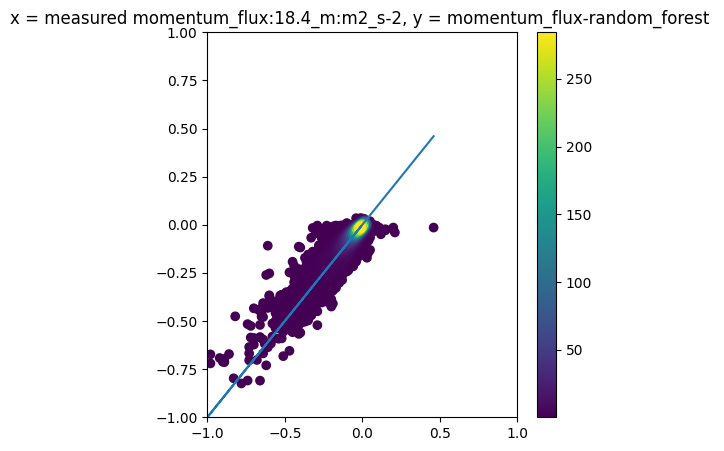

In [165]:

#
#  Random forest predictions look cut off at .08: strange!
#
xStr=  exact_predictand1
yStr = predictand1 + '-random_forest'
x = pred[xStr]
y = pred[yStr]
#clr = pred['stabParm']
print( pred[yStr].loc[ pred[yStr] < .08].count())
print( pred[xStr].loc[ pred[xStr] < .08].count())
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
fig, ax = plt.subplots(figsize = (5,5))

im = ax.scatter(x,y, c=z )
    #ax[i].axis('equal')
ax.set_xlim(.0, 1)
ax.set_ylim(.0, 1)
#ax.set_xticks([0,.2,.4,.6,.8,1.0])
#ax.set_yticks([0,.2,.4,.6,.8,1.0])
fig.colorbar(im, ax = ax)
titleStr = "x = measured {0}, y = {1} ". format(xStr, yStr)
ax.set_title(titleStr )
m, b = np.polyfit(x, y, 1)
ax.plot(x, x)
# plt.ylim(-0.0, 0.1)
# plt.xlim(-0.0, 0.1)
plt.ylim(-1, 1)
plt.xlim(-1, 1)



4162


(-1.0, 1.0)

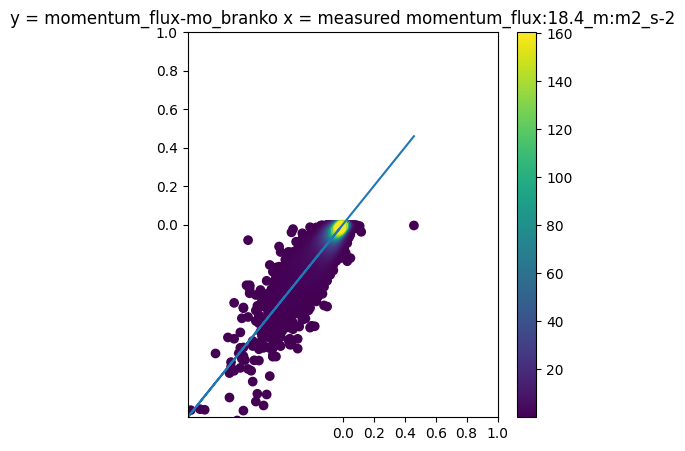

In [148]:

from scipy.stats import *
import matplotlib.pyplot as plt
import numpy as np
#
#  plot friction-vel scatter plot as computed by mo.py and make sure
#  calculations in mo.py reflect the calculations in this notebook. 
#  (I attached the columns from this notebook to the testing and training data, so the 
#.   most output can be examined as calculated in mo.py or here)
#
print(pred[predictand1 + mo_version].isna().sum())
pred2 = pred.loc[pred[predictand1 + mo_version].isna() == False]
xStr=  exact_predictand1
yStr = predictand1 + mo_version
x = pred2[xStr]
y = pred2[yStr]


xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y,z = x[idx], y[idx], z[idx]
fig, ax = plt.subplots(figsize = (5,5))

im = ax.scatter(x,y, c=z )
   
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([0,.2,.4,.6,.8,1.0])
ax.set_yticks([0,.2,.4,.6,.8,1.0])
fig.colorbar(im, ax = ax)
titleStr = "y = {0} x = measured {1}". format(yStr, xStr)
ax.set_title(titleStr )
m, b = np.polyfit(x, y, 1)
ax.plot(x, x)


# plt.ylim(-0.0, 0.1)
# plt.xlim(-0.0, 0.1)
plt.ylim(-1, 1)
plt.xlim(-1, 1)


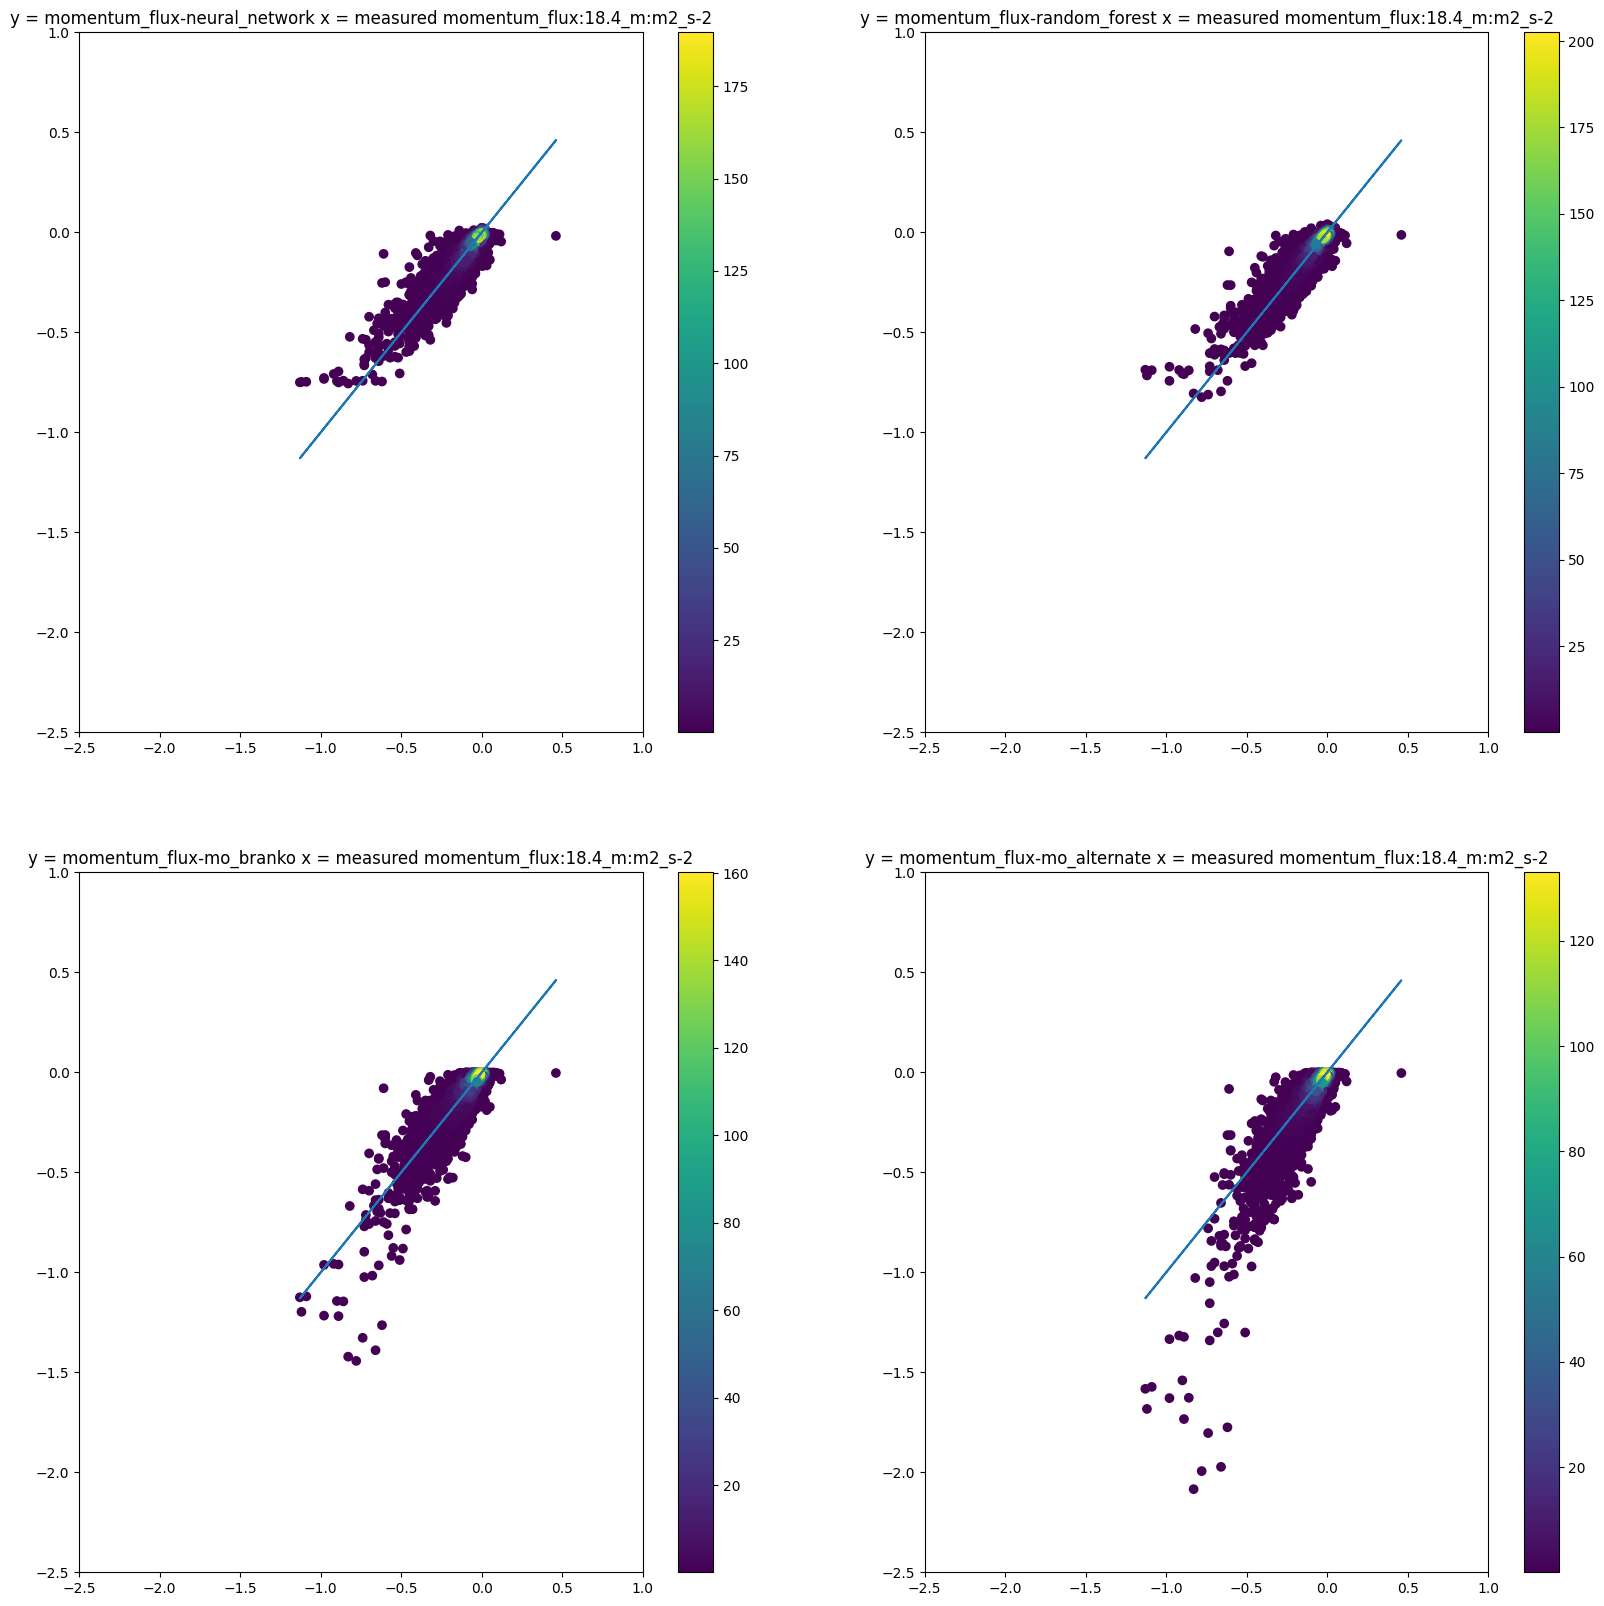

In [28]:

#
# Create some scatter plots for quick visual comparison of ML models and also MOST calcs
#


xStr=  exact_predictand1

yStr = []

yStr.append(predictand1 + '-neural_network')
yStr.append(predictand1 + '-random_forest')
# yStr.append('MOSTustar')
yStr.append(predictand1+ mo_version)
yStr.append(predictand1+ mo_version2)


# pred2 = pred.loc[pred['MOSTustar'].isna() == False]
pred2 =  pred.loc[pred[predictand1 + mo_version].isna() == False]
pred2 =  pred.loc[pred[predictand1 + mo_version2].isna() == False]

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize = (20,20))
ax = ax.flat
for i in range (0,len(ax)):
    x = pred2[xStr]
    y = pred2[yStr[i]]
        
    # if yStr[i] == predictand1 + '-neural_network':
    #     y = pred2[yStr[i]]*scaleUstar + meanUstar

    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    # idx = z.argsort()
    # x, y, z = x[idx], y[idx], z[idx]


    im = ax[i].scatter(x,y,  c=z )
    #ax[i].axis('equal')
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    # ax[i].set_xticks([0,.2,.4,.6,.8,1.0])
    # ax[i].set_yticks([0,.2,.4,.6,.8,1.0])
    fig.colorbar(im, ax = ax[i])
    titleStr = "y = {0} x = measured {1}". format(yStr[i], xStr)
    ax[i].set_title(titleStr )
    m, b = np.polyfit(x, y, 1)
    ax[i].plot(x, x)

    ax[i].set_xlim(-2.5,1)
    ax[i].set_ylim(-2.5,1)



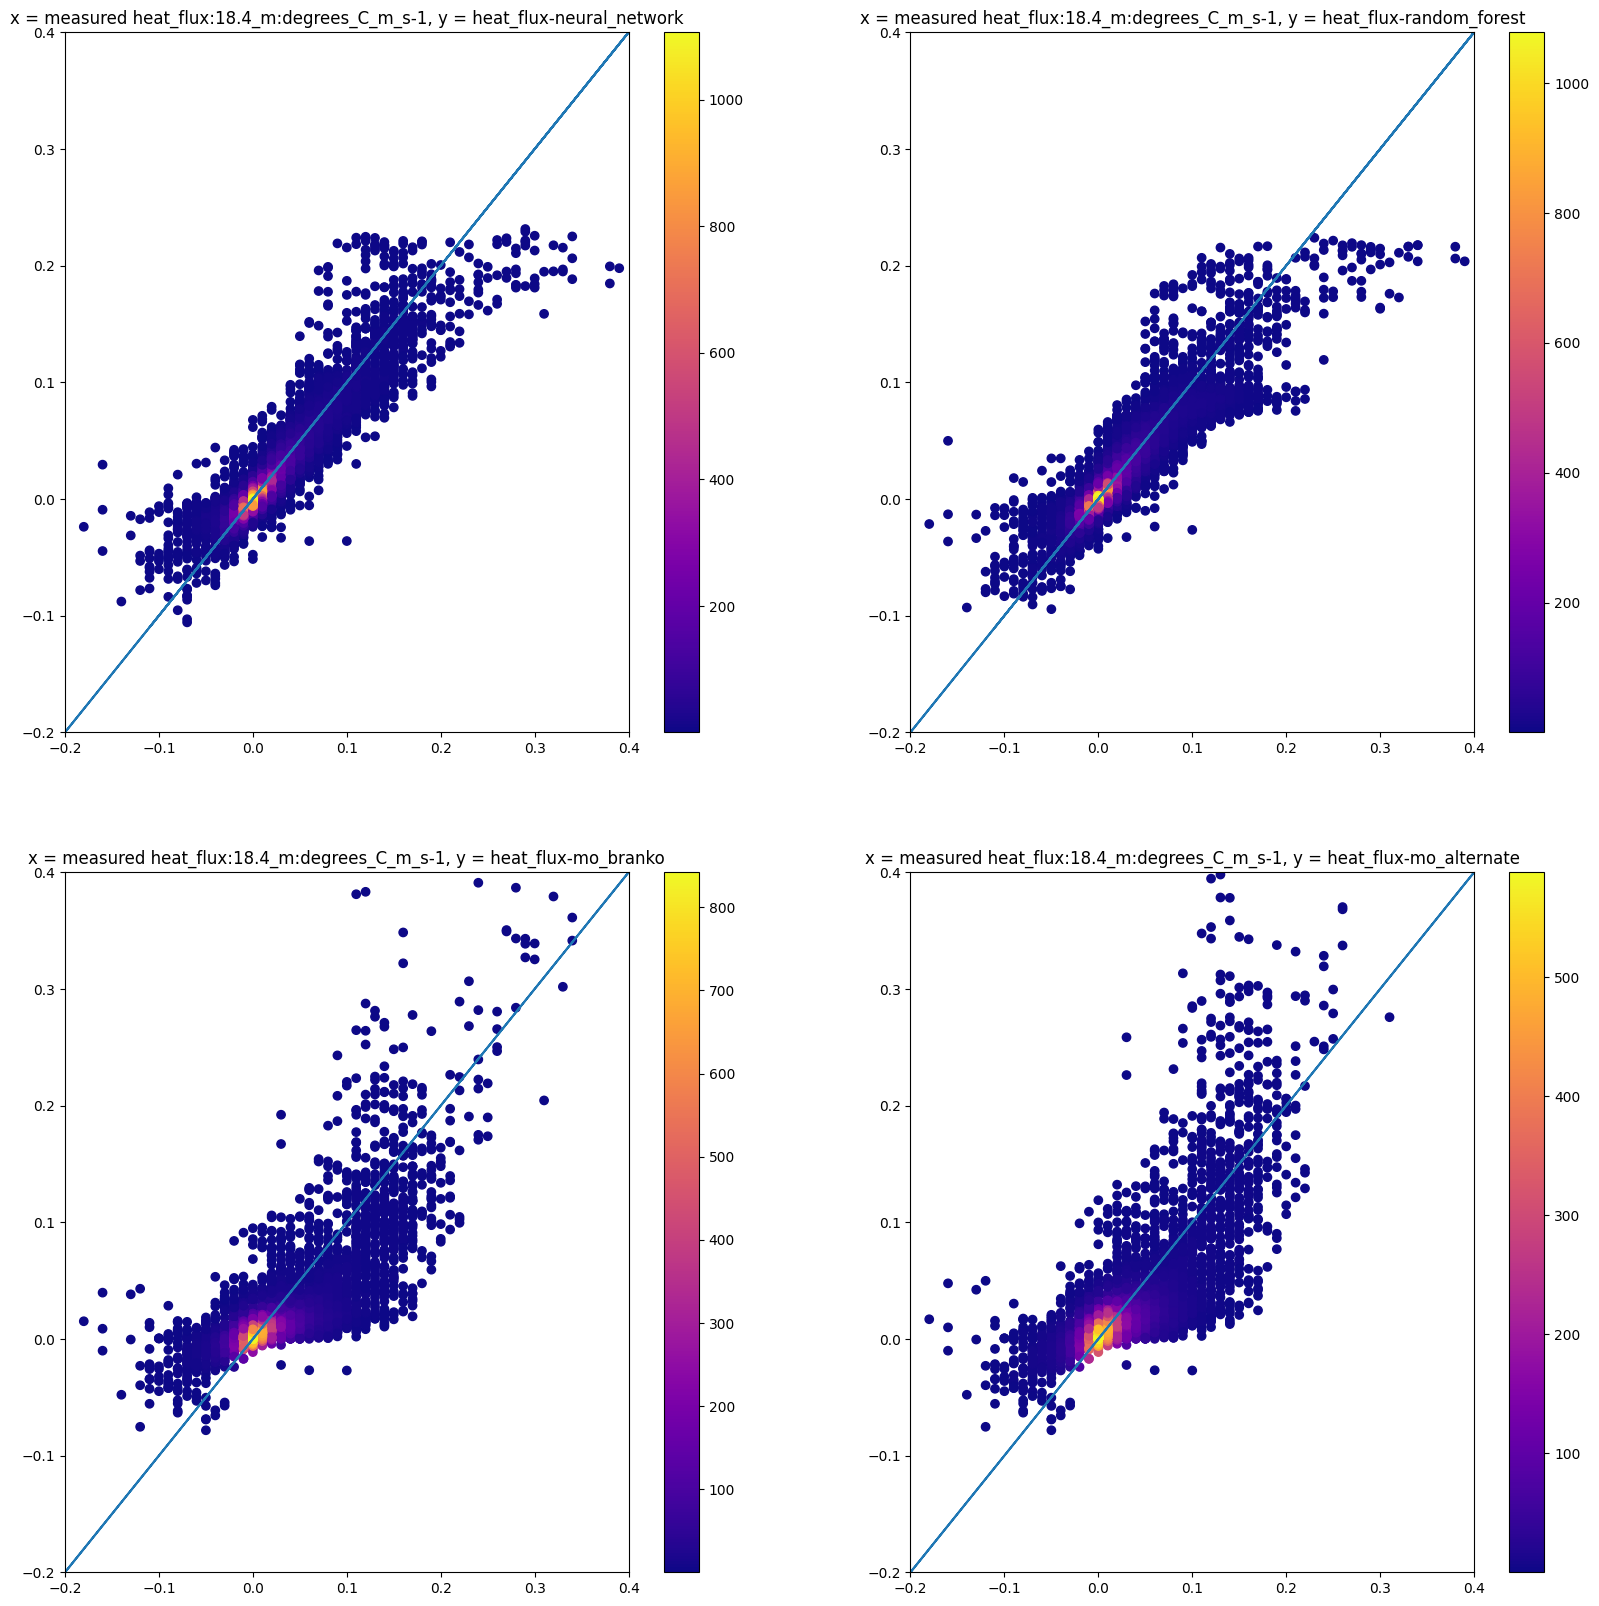

In [29]:

#
# Create some scatter plots for quick visual comparison of ML models and also MOST calcs
#

xStr = exact_predictand2

yStr = []

yStr.append(predictand2+ '-neural_network')
yStr.append(predictand2+ '-random_forest')
# yStr.append('TempScaleMOST')
yStr.append(predictand2+ mo_version)
yStr.append(predictand2+ mo_version2)


pred2 = pred.loc[pred[predictand2+ mo_version].isna() == False]
pred2 = pred.loc[pred[predictand2+ mo_version2].isna() == False]

# pred2 = pred2.loc[pred2['TempScaleMOST'].isna() == False]
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# fig, ax = plt.subplots(2,2, figsize = (20,20))
fig, ax = plt.subplots(2,2, figsize = (20,20))
ax = ax.flat
for i in range (0,len(ax)):
    
    x = pred2[xStr]
    y = pred2[yStr[i]]
        
    # if yStr[i] == predictand2+ '-neural_network':
    #     y =   pred2[yStr[i]]* scaleTscale + meanTscale,
    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    #idx = z.argsort()
    #x, y, z = x[idx], y[idx], z[idx]


    im = ax[i].scatter(x,y,  c=z, cmap = 'plasma')
   
    ax[i].set_xlim(-.2,.4)
    ax[i].set_ylim(-.2,.4)
    fig.colorbar(im, ax = ax[i])
    titleStr = "x = measured {0}, y = {1}". format(xStr, yStr[i])
    ax[i].set_title(titleStr )
    #m, b = np.polyfit(x, y, 1)
    ax[i].plot(x, x)

    # ax[i].set_xlim(-.2,.2)
    # ax[i].set_ylim(-1000,1000)



In [ ]:
def draw_scatter():

    #
    # Create some scatter plots for quick visual comparison of ML models and also MOST calcs
    #

    xStr = exact_predictand2

    yStr = []

    yStr.append(predictand2+ '-neural_network')
    yStr.append(predictand2+ '-random_forest')
    # yStr.append('TempScaleMOST')
    yStr.append(predictand2+ mo_version)
    yStr.append(predictand2+ mo_version2)


    pred2 = pred.loc[pred[predictand2+ mo_version].isna() == False]
    pred2 = pred.loc[pred[predictand2+ mo_version2].isna() == False]

    # pred2 = pred2.loc[pred2['TempScaleMOST'].isna() == False]
    from scipy.stats import gaussian_kde
    import matplotlib.pyplot as plt

    # fig, ax = plt.subplots(2,2, figsize = (20,20))
    fig, ax = plt.subplots(2,2, figsize = (20,20))
    ax = ax.flat
    for i in range (0,len(ax)):
        
        x = pred2[xStr]
        y = pred2[yStr[i]]
            
        # if yStr[i] == predictand2+ '-neural_network':
        #     y =   pred2[yStr[i]]* scaleTscale + meanTscale,
        xy = np.vstack([x,y])
        z = gaussian_kde(xy)(xy)

        #idx = z.argsort()
        #x, y, z = x[idx], y[idx], z[idx]


        im = ax[i].scatter(x,y,  c=z, cmap = 'plasma')
    
        ax[i].set_xlim(-.2,.4)
        ax[i].set_ylim(-.2,.4)
        fig.colorbar(im, ax = ax[i])
        titleStr = "x = measured {0}, y = {1}". format(xStr, yStr[i])
        ax[i].set_title(titleStr )
        #m, b = np.polyfit(x, y, 1)
        ax[i].plot(x, x)

        # ax[i].set_xlim(-.2,.2)
        # ax[i].set_ylim(-1000,1000)



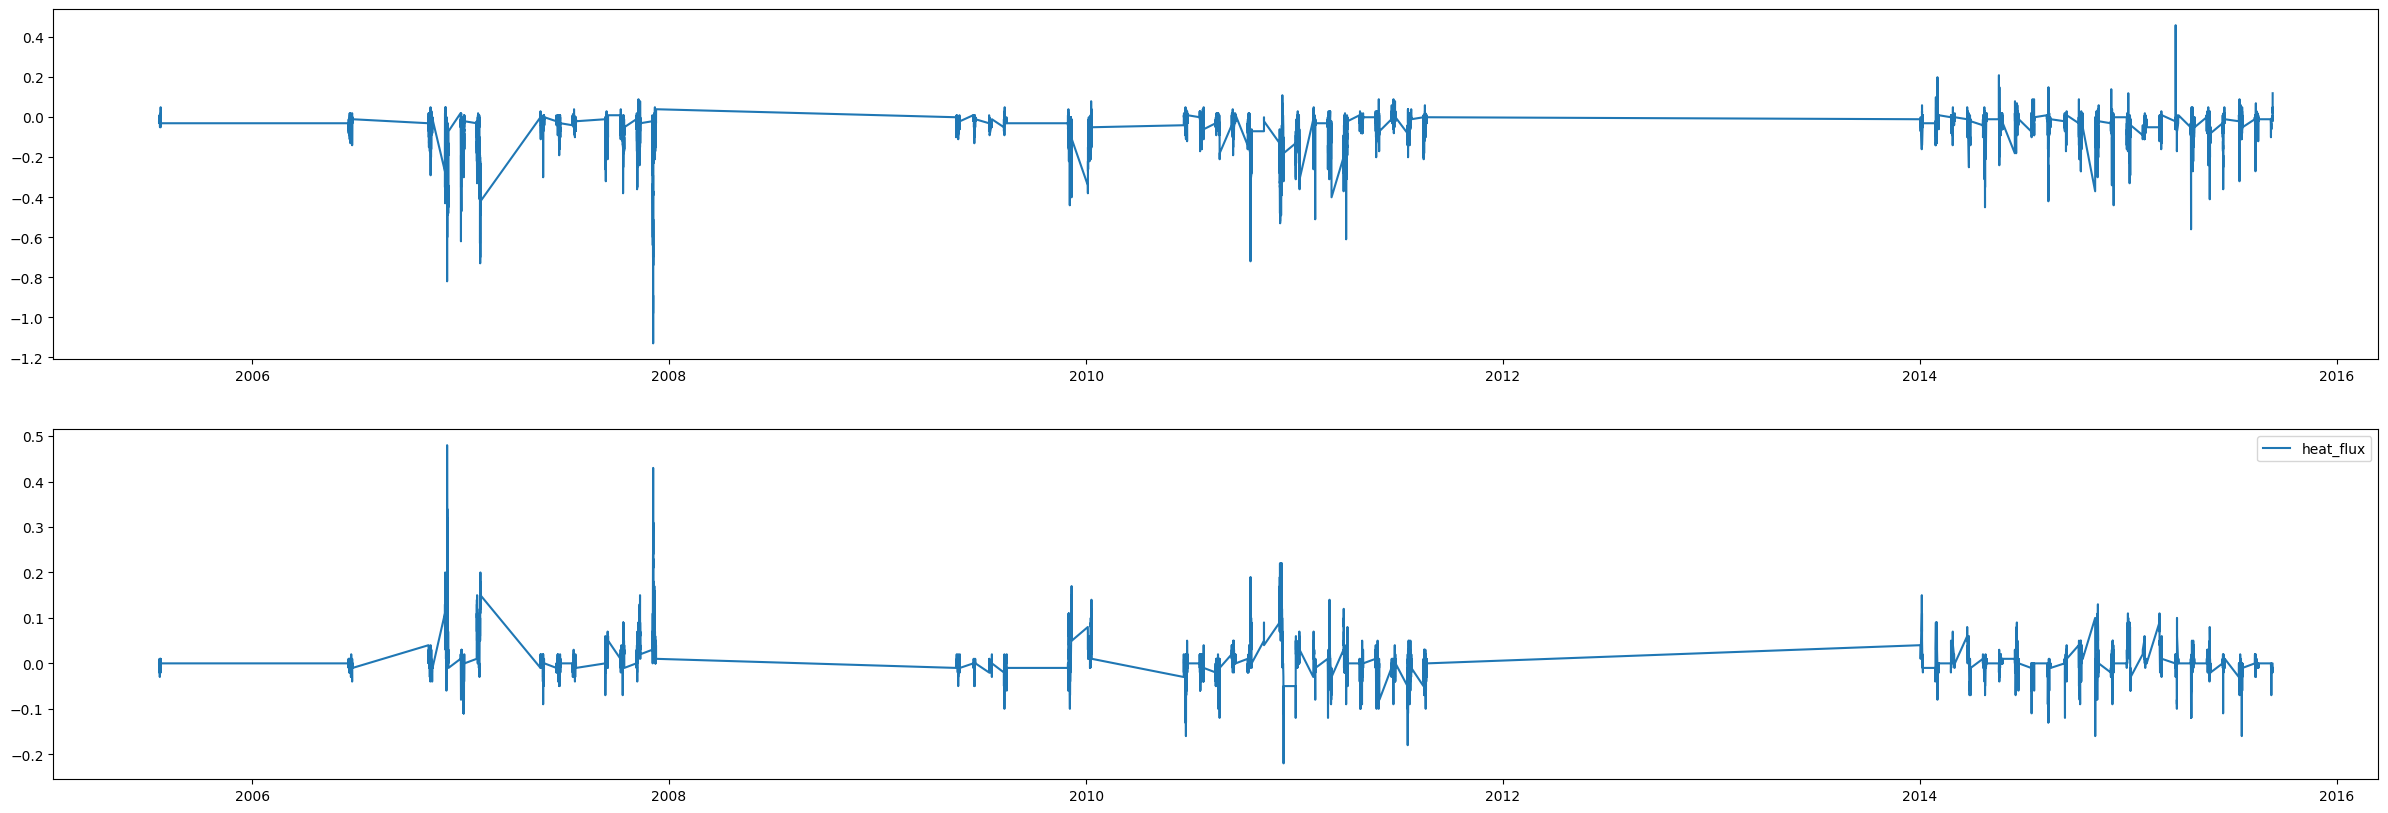

In [32]:
fig, ax = plt.subplots(2,1, figsize=(30,10))
ax = ax.flat
ax[0].plot(pred['Time'], pred[exact_predictand1], label=predictand1)
ax[1].plot(pred['Time'], pred[exact_predictand2], label=predictand2)
plt.legend()
plt.show()

In [26]:
def drawTimeSeries(ax, predictions, exact_predictand, predictand, model_type="neural_network"):
    if model_type != "neural_network":
        model_type = "random_forest"
    #
    #  Random forest predictions look cut off at .08: strange!
    #
    # x = predictions['Time'].astype(str)
    x = predictions['Time']
    # x = predictions['Time'].index

    y_true=  exact_predictand
    y_pred = predictand + '-' + model_type

    if model_type == "neural_network":
        colorPred = 'purple'
    elif model_type == "random_forest":
        colorPred = 'red'

    y_true = predictions[y_true]
    y_pred = predictions[y_pred]

    #clr = pred['stabParm']

    # xy = np.vstack([x,y])
    # z = gaussian_kde(xy)(xy)
    # idx = z.argsort()
    # x, y, z = x[idx], y[idx], z[idx]

    # fig, ax = plt.subplots(figsize = (5,5))



    # ax.scatter(x,y)
    ax.plot(x,y_true, color='black', label=predictand + 'true')
    ax.plot(x,y_pred, color=colorPred, label=predictand + 'pred')
        #ax[i].axis('equal')
    # ax.set_xlim(.0, 1)
    # ax.set_ylim(.0, 1)
    #ax.set_xticks([0,.2,.4,.6,.8,1.0])
    #ax.set_yticks([0,.2,.4,.6,.8,1.0])
    # fig.colorbar(im, ax = ax)
    titleStr = "{0} : {1} ". format(predictand, model_type)
    ax.set_title(titleStr )

    # m, b = np.polyfit(x, y, 1)
    # ax.plot(x, x)
    # plt.ylim(-0.0, 0.1)
    # plt.xlim(-0.0, 0.1)
    # plt.ylim(-1, 1)
    # plt.xlim(-1, 1)


    # fig.hl_span("3/18/2013", "4/08/2013", color='red')

    return ax

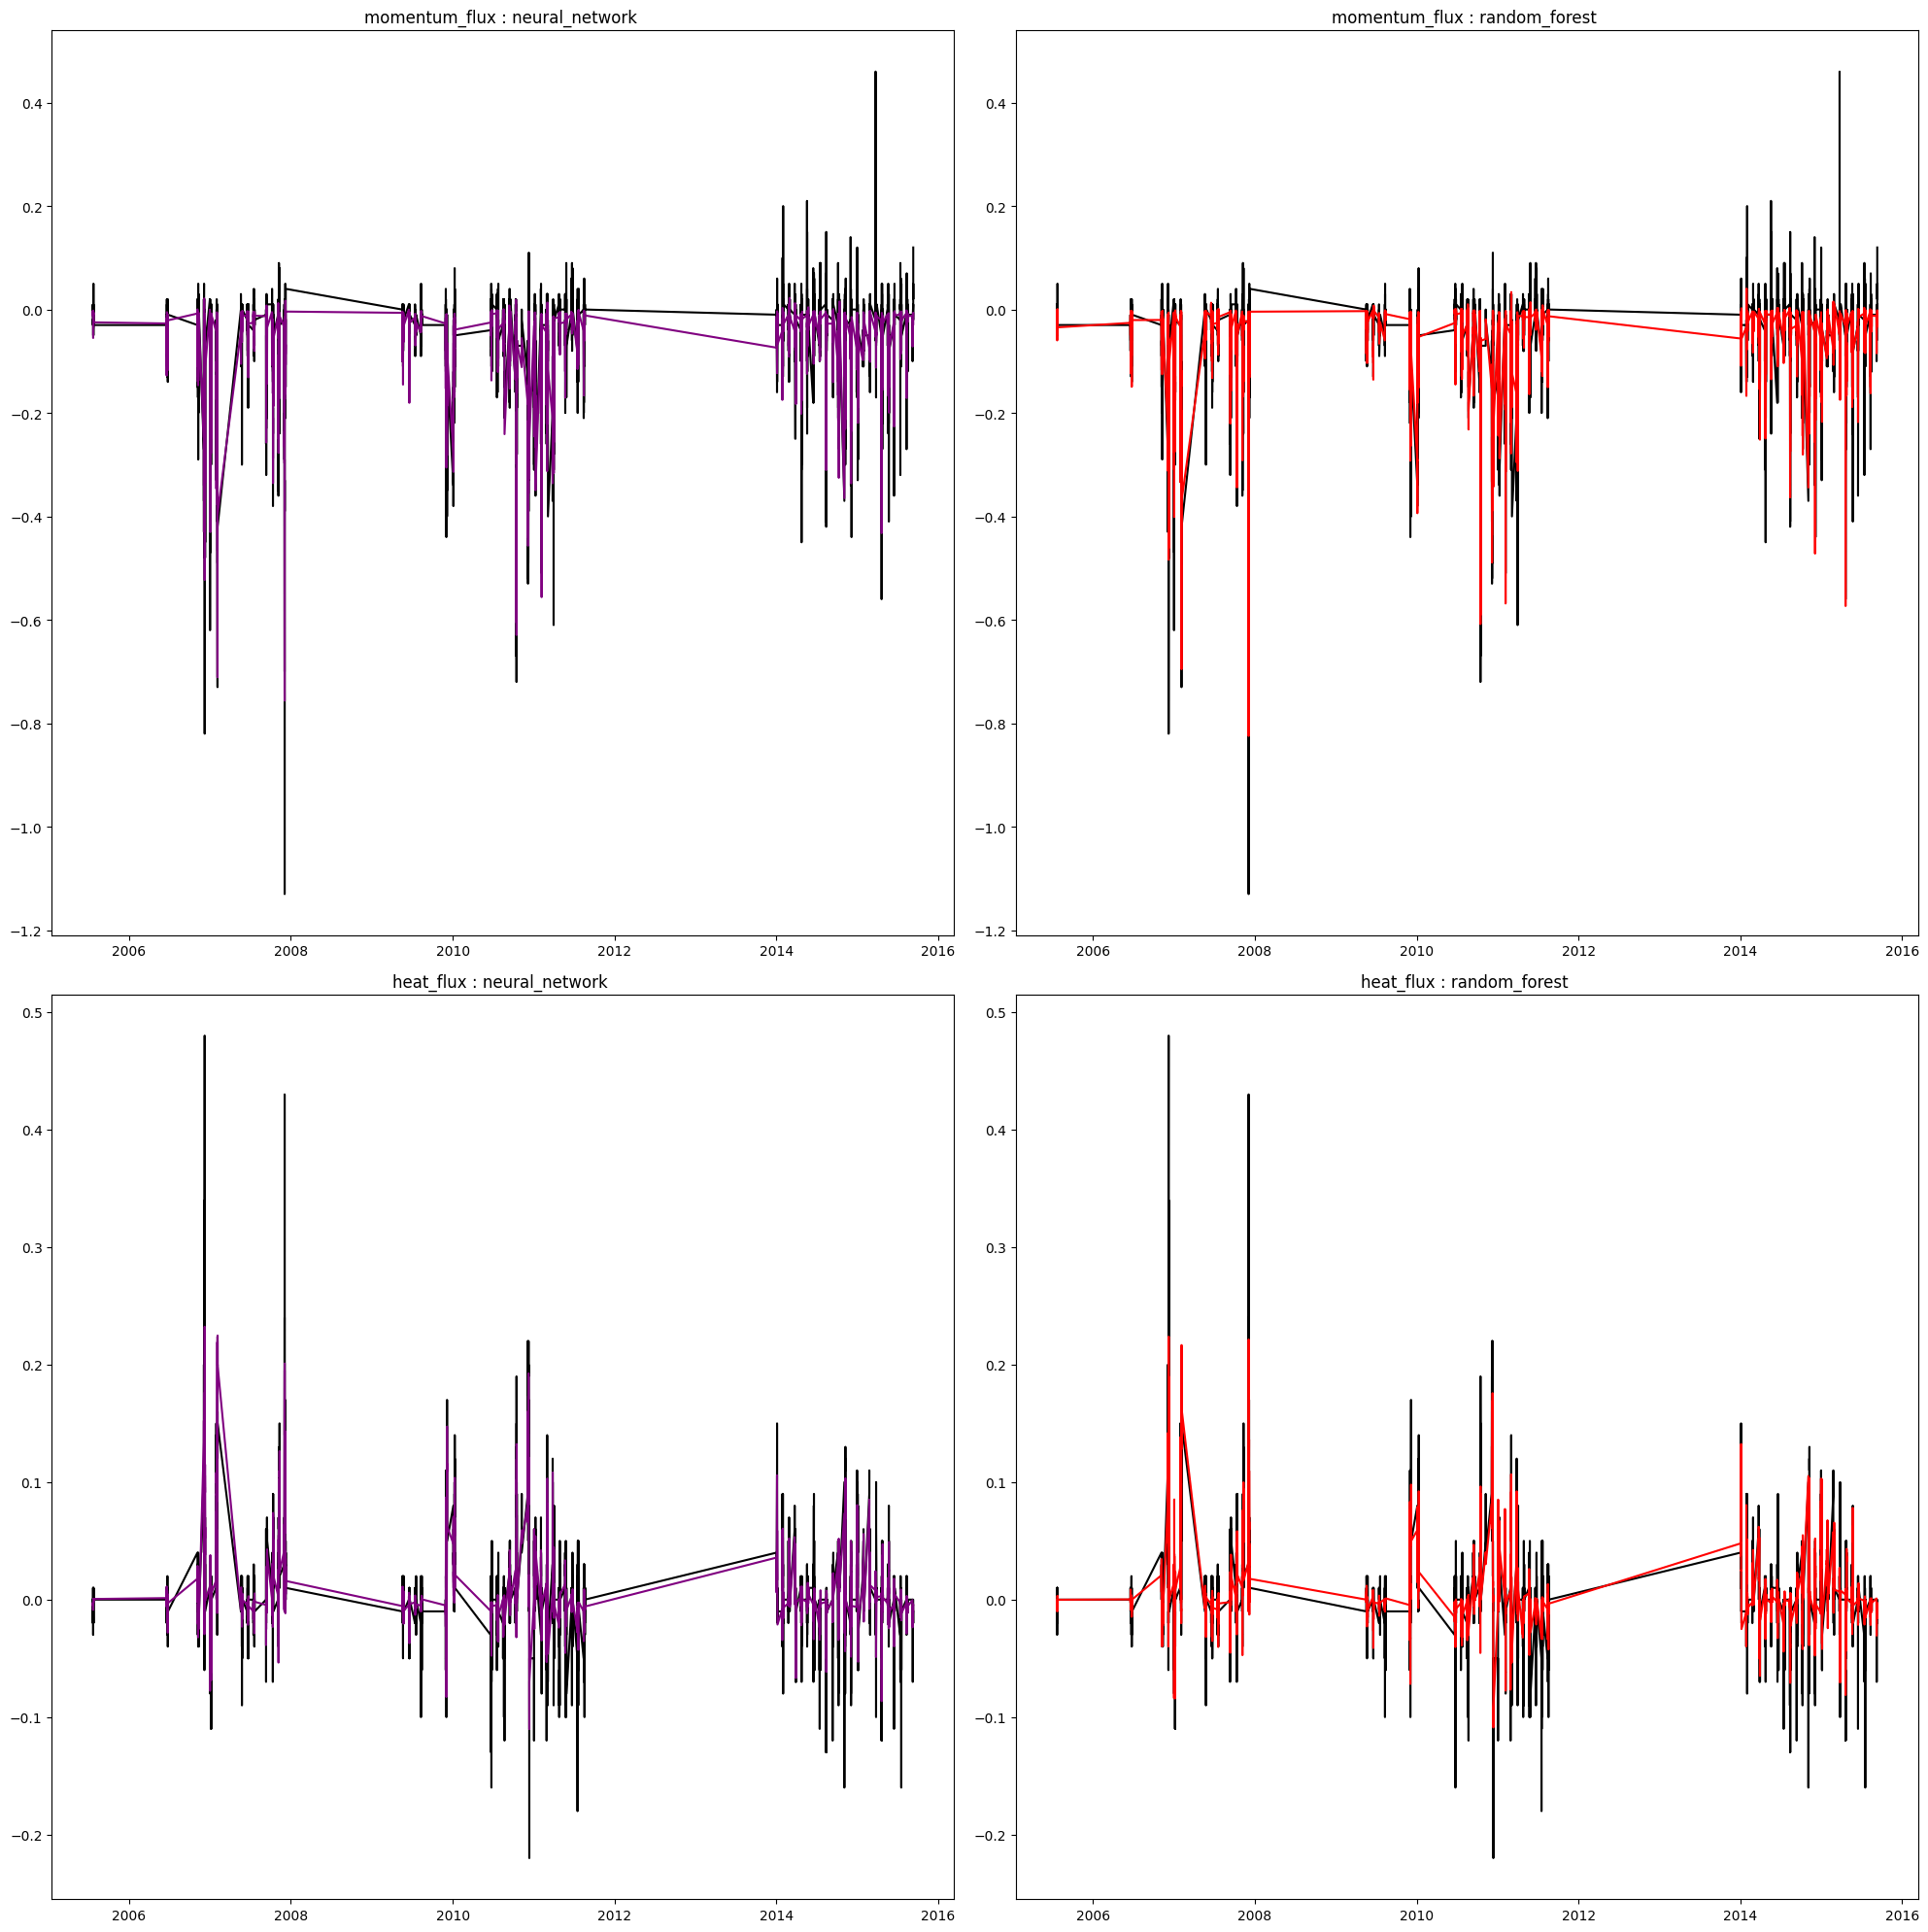

In [27]:
plot_obs = [
    (pred, exact_predictand1, predictand1, 'neural_network'),
    (pred, exact_predictand1, predictand1, 'rf'),
    (pred, exact_predictand2, predictand2, 'neural_network'),
    (pred, exact_predictand2, predictand2, 'rf')
]

fig, axs = plt.subplots(2,2, figsize=(20,20))
ax = axs.flat

for ax, (p, ep, pr, mt) in zip(axs.flat, plot_obs):
    drawTimeSeries(ax, p, ep, pr, model_type=mt)

fig.tight_layout()
plt.show()


# FINO code below

In [ ]:


import pandas as pd
impNn = pd.read_csv(directory + "/friction_velocity_neural_network_importances.csv")

impNn['aveImp'] = abs(impNn[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impNn[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impNn[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'NN U* Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
import pandas as pd
impRf = pd.read_csv(directory + "/friction_velocity_random_forest_importances.csv")

#impRf = pd.read_csv("/d1/FINO1/friction_velocity40_random_forest_importances4.csv")
#impTempSc = pd.read_csv("/d1/FINO1/temp_scale40_random_forest_importances5.csv")

impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impRf[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'RF U* Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
import pandas as pd
impNn = pd.read_csv(directory + "/temp_scale_neural_network_importances.csv")


impNn['aveImp'] = abs(impNn[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impNn[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impNn[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'NN Temp Scale Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
import pandas as pd
impRf = pd.read_csv(directory + "/temp_scale_neural_network_importances.csv")

#impRf = pd.read_csv("/d1/FINO1/friction_velocity40_random_forest_importances4.csv")
#impTempSc = pd.read_csv("/d1/FINO1/temp_scale40_random_forest_importances5.csv")

impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impRf[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'NN Temp Scale Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
import pandas as pd

impRf = pd.read_csv(directory + "/temp_scale_random_forest_importances.csv")

#impRf = pd.read_csv("/d1/FINO1/friction_velocity40_random_forest_importances4.csv")
#impTempSc = pd.read_csv("/d1/FINO1/temp_scale40_random_forest_importances5.csv")

impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impRf[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'RF Temp Scale Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])

import pandas as pd
impRf = pd.read_csv(directory + "/friction_velocity_random_forest_importances.csv")
impTempSc = pd.read_csv(directory + "/temp_scale_random_forest_importances.csv")

#impRf = pd.read_csv("/d1/FINO1/friction_velocity40_random_forest_importances4.csv")
#impTempSc = pd.read_csv("/d1/FINO1/temp_scale40_random_forest_importances5.csv")

print(impRf.columns)
impRf['aveImpStable'] = abs(impRf[[ 'stable_0', 'stable_1', 'stable_2', 'stable_3', 'stable_4']].mean(axis = 1 ))
impRf['aveImpUnstable'] = abs(impRf[[ 'unstable_0', 'unstable_1', 'unstable_2', 'unstable_3', 'unstable_4']].mean(axis = 1 ))
impRf['aveImpNeutral'] = abs(impRf[[ 'neutral_0', 'neutral_1', 'neutral_2', 'neutral_3', 'neutral_4']].mean(axis = 1 ))
print (impRf[['input', 'aveImpStable']].sort_values(by = 'aveImpStable'))
print (impRf[['input', 'aveImpUnstable']].sort_values(by = 'aveImpUnstable'))
print (impRf[['input', 'aveImpNeutral' ]].sort_values(by = 'aveImpNeutral'))
barPlotImpUnstable = impRf[['input', 'aveImpUnstable']].sort_values(by = 'aveImpUnstable')
barPlotImpStable = impRf[['input', 'aveImpStable', 'aveImpUnstable']].sort_values(by = 'aveImpUnstable')
barPlotImpNeutral = impRf[['input', 'aveImpNeutral','aveImpUnstable']].sort_values(by = 'aveImpUnstable')

print(impTempSc.columns)
impTempSc['aveImpStable'] = abs(impTempSc[[ 'stable_0', 'stable_1', 'stable_2', 'stable_3', 'stable_4']].mean(axis = 1 ))
impTempSc['aveImpUnstable'] = abs(impTempSc[[ 'unstable_0', 'unstable_1', 'unstable_2', 'unstable_3', 'unstable_4']].mean(axis = 1 ))
impTempSc['aveImpNeutral'] = abs(impTempSc[[ 'neutral_0', 'neutral_1', 'neutral_2', 'neutral_3', 'neutral_4']].mean(axis = 1 ))
print (impTempSc[['input', 'aveImpStable']].sort_values(by = 'aveImpStable'))
print (impTempSc[['input', 'aveImpUnstable']].sort_values(by = 'aveImpUnstable'))
print (impTempSc[['input', 'aveImpNeutral']].sort_values(by = 'aveImpNeutral'))

print(impTempSc.columns)
barPlotImpTScUnstable = impTempSc[['input', 'aveImpUnstable']].sort_values(by = 'aveImpUnstable')
#barPlotImpTScStable = impTempSc[['input', 'aveImpStable']].sort_values(axis =1, by = ['water_sfc_temperature:0_m:K','zenith:0_m:degrees','angleBetweenWaveWind','relative_humidity:40_m:%','potential_temperature_gradient:20_m:K_m-1', 'mixing_ratio:40_m:g_kg-1','potential_temperature:40_m:K', 'wave_period:0_m:s','bulk_richardson:40_m:none','wave_dir_linear_interp:0_m:degrees','wind_speed_gradient:20_m:s-1','v_wind:40_m:m_s-1','wave_height:0_m:m', 'u_wind:40_m:m_s-1'])
barPlotImpTScStable = impTempSc[['input', 'aveImpStable', 'aveImpUnstable']].sort_values(by ='aveImpUnstable')
barPlotImpTScNeutral = impTempSc[['input', 'aveImpNeutral','aveImpUnstable']].sort_values(by = 'aveImpUnstable')

ax = barPlotImpUnstable.plot.barh( color = 'blue',x ='input',y = 'aveImpUnstable', title =  'U* Pred Imp Unstable Regime')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
#ax.set_xticks([0, .005,  .01, .015,.02])
#ax.set_xticklables([])
ax = barPlotImpNeutral.plot.barh( color ='red', x ='input',y = 'aveImpNeutral', title =  '       Neutral Regime')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
#ax.set_xticks([0, .005,  .01, .015,.02])
ax = barPlotImpStable.plot.barh( color= 'green',x ='input',y = 'aveImpStable', title =  '        Stable Regime')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
#ax.set_xticks([0, .005,  .01, .015,.02,])
ax = barPlotImpTScUnstable.plot.barh(color = 'blue', x ='input',y = 'aveImpUnstable', title =  'Temp Scale Predictor Importances For Unstable Regime')
ax.set_xticks([0,.0002,.0004,.0006,  .0008,.0010,.0012])
ax = barPlotImpTScNeutral.plot.barh(color= 'red', x ='input',y = 'aveImpNeutral', title =  'Neutral Regime                                                         ')
ax.set_xticks([0,.0002,.0004,.0006,  .0008,.0010,.0012])
ax = barPlotImpTScStable.plot.barh(color ='green', x ='input',y = 'aveImpStable', title =  'Stable Regime                                             ')
ax.set_xticks([0,.0002,.0004,.0006,  .0008,.0010,.0012])
xStr=  'friction_velocity:40_m:m_s-1'
cols = [ #'L', 'global_horizontal_irradiance:30_m:W_m-2',
        #'zenith:0_m:degrees', 'azimuth:0_m:degrees', 'temperature:40_m:K',
        #'temperature:60_m:K', 'temperature:80_m:K',
        'water_sfc_temperature:0_m:K', 'pressure:0_m:hPa', 'pressure:40_m:hPa',
       #'pressure:60_m:hPa', 'pressure:80_m:hPa',
       'potential_temperature:40_m:K', 
       #'potential_temperature:60_m:K',
       #'potential_temperature:80_m:K',
       'skin_virtual_potential_temperature:0_m:K', 
        'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 
       #'mixing_ratio:60_m:g_kg-1',
       #'mixing_ratio:80_m:g_kg-1', 'relative_humidity:40_m:%',
       #'relative_humidity:60_m:%', 'relative_humidity:80_m:%',
       'wave_dir_linear_interp:0_m:degrees', 'wave_height:0_m:m',
       'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1',
       'wind_speed:40_m:m_s-1', 'wind_direction:40_m:degrees',
      # 'wind_speed:60_m:m_s-1', 'wind_direction:60_m:degrees',
      # 'wind_speed:80_m:m_s-1', 'wind_direction:80_m:degrees',
       'u_wind:40_m:m_s-1', 'v_wind:40_m:m_s-1', #'u_wind:60_m:m_s-1',
       #'v_wind:60_m:m_s-1', 'u_wind:80_m:m_s-1', 'v_wind:80_m:m_s-1',
       #'bulk_richardson:40_m:none', 'bulk_richardson:60_m:none',
       #'bulk_richardson:80_m:none',
       'potential_temperature_gradient:20_m:K_m-1',
       #'potential_temperature_gradient:40_m:K_m-1',
       'wind_speed_gradient:20_m:s-1',
       #'wind_speed_gradient:40_m:s-1',
       #'sensible_heat_flux:40_m:W_m-2', 
       'wind_direction:40_m:degrees','angleBetweenWaveWind']
cols = ['wind_speed:40_m:m_s-1', 'wind_direction:40_m:degrees','u_wind:40_m:m_s-1', 'v_wind:40_m:m_s-1',
        'wind_speed_gradient:20_m:s-1','wave_dir_linear_interp:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
        'potential_temperature:40_m:K','pressure:40_m:hPa', 
        'angleBetweenWaveWind', 'mixing_ratio:40_m:g_kg-1', ]
print(len(cols))


In [ ]:


fig, axs = plt.subplots(6,2, figsize=(30, 50))
x = pred[xStr]
y = pred['MOSTustar']
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

for i in range(0,len(cols)):
    vmin = None
    vmax = None
    if cols[i] == "bulk_richardson:40_m:none":
        vmin = -.02
        vmax = .02
    elif cols[i] == "L":
        vmin = 0
        vmax = 50
    
    elif cols[i] == "potential_temperature_gradient:20_m:K_m-1":
        vmin = -.01
        vmax = .02
    elif cols[i] ==  "wind_speed_gradient:20_m:s-1":
        vmin = -.02
        vmax = .02
    elif cols[i] ==  "sensible_heat_flux:40_m:W_m-2":
        vmin = .05
        vmax = -.05
    ax = axs.flat[i]
    #t = pred[cols[i]]
    t= pred[cols[i]][idx]
    im = ax.scatter(x,y,  c=t, vmin = vmin, vmax = vmax, cmap = 'plasma')
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xticks([0,.2,.4,.6,.8,1.0])
    ax.set_yticks([0,.2,.4,.6])
    fig.colorbar(im,ax=ax)
    cstr = "MOSTu* vs Obs color= {0}".format(cols[i])
    ax.set_title(cstr, fontsize=30)
    m, b = np.polyfit(x, y, 1)
    plt.subplots_adjust(wspace=.1, hspace=.3)
    ax.plot(x, x)
    


In [ ]:
#
# Look at correlation of predictors and predictand 
# 
#
import seaborn as sns
import matplotlib.pyplot as plt


#
# Correlation map
# 
f, ax = plt.subplots(figsize=(10, 10))
# 'mixing_ratio:40_m:g_kg-1', potential_temperature:40_m:K', 'relative_humidity:40_m:%', 'pressure:40_m:hPa', potential_temperature:40_m:K', 'relative_humidity:40_m:%', 'pressure:40_m:hPa'
# 'potential_temperature:40_m:K','temperature:40_m:K', 'pressure:40_m:hPa' 
# 'bulk_richardson:40_m:none','mixing_ratio:40_m:g_kg-1', 'potential_temperature:40_m:K', 'relative_humidity:40_m:%','skin_virtual_potential_temperature:0_m:K','wind_speed:40_m:m_s-1'

corr = der[[ #'global_horizontal_irradiance:30_m:W_m-2',
"zenith:0_m:degrees",
#"azimuth:0_m:degrees",
#"temperature:40_m:K",
#"temperature:60_m:K",
#"temperature:80_m:K",
"water_sfc_temperature:0_m:K",
#"pressure:0_m:hPa",
#"pressure:40_m:hPa",
#"pressure:60_m:hPa",
#"pressure:80_m:hPa",
"potential_temperature:40_m:K",
#"potential_temperature:60_m:K",
#"potential_temperature:80_m:K",
#"skin_virtual_potential_temperature:0_m:K",
#"mixing_ratio:0_m:g_kg-1",
"mixing_ratio:40_m:g_kg-1",
#"mixing_ratio:60_m:g_kg-1",
#"mixing_ratio:80_m:g_kg-1",
"relative_humidity:40_m:%",
#"relative_humidity:60_m:%",
#"relative_humidity:80_m:%",
"wave_dir_linear_interp:0_m:degrees",
"wave_height:0_m:m",
"wave_period:0_m:s",
#"wave_phase_speed:0_m:m_s-1",
"wind_speed:40_m:m_s-1",
#"wind_direction:40_m:degrees",
#"wind_speed:60_m:m_s-1",
#"wind_direction:60_m:degrees",
#"wind_speed:80_m:m_s-1",
#"wind_direction:80_m:degrees",
"u_wind:40_m:m_s-1",
"v_wind:40_m:m_s-1",
#"u_wind:60_m:m_s-1",
#"v_wind:60_m:m_s-1",
#"u_wind:80_m:m_s-1",
#"v_wind:80_m:m_s-1",
"bulk_richardson:40_m:none",
#"bulk_richardson:60_m:none",
#"bulk_richardson:80_m:none",
"potential_temperature_gradient:20_m:K_m-1",
#"potential_temperature_gradient:40_m:K_m-1",
"wind_speed_gradient:20_m:s-1",
#"wind_speed_gradient:40_m:s-1"
#"sensible_heat_flux:40_m:W_m-2"

            ]].corr()

sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
            square=True, ax=ax, annot=True, vmin= -1, vmax= 1)

#sns.heatmap(corr[['next30Kt']].sort_values(by=['next30Kt'],ascending = False),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
#          ax=ax, annot=True, vmin=-1, vmax = 1)
cmap=sns.diverging_palette(220, 10, as_cmap=True)
plt.show()
plt.close()


cubistCols = ['Time','global_horizontal_irradiance:30_m:W_m-2', 'zenith:0_m:degrees',
       'azimuth:0_m:degrees', 'temperature:30_m:K', 'temperature:40_m:K',
       'temperature:50_m:K', 'temperature:60_m:K', 'temperature:80_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:0_m:hPa', 'pressure:30_m:hPa',
       'pressure:40_m:hPa', 'pressure:50_m:hPa', 'pressure:60_m:hPa',
       'pressure:80_m:hPa', 'potential_temperature:30_m:K',
       'potential_temperature:40_m:K', 'potential_temperature:50_m:K',
       'potential_temperature:60_m:K', 'potential_temperature:80_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 'mixing_ratio:60_m:g_kg-1',
       'mixing_ratio:80_m:g_kg-1', 'relative_humidity:40_m:%',
       'relative_humidity:60_m:%', 'relative_humidity:80_m:%',
       'wave_dir:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
       'wave_phase_speed:0_m:m_s-1', 'wind_speed:40_m:m_s-1',
       'wind_speed:60_m:m_s-1', 'wind_speed:80_m:m_s-1',
       'wind_direction:40_m:degrees', 'wind_direction:60_m:degrees',
       'wind_direction:80_m:degrees', 'u_wind:40_m:m_s-1', 'v_wind:40_m:m_s-1',
       'u_wind:60_m:m_s-1', 'v_wind:60_m:m_s-1', 'u_wind:80_m:m_s-1',
       'v_wind:80_m:m_s-1', 'bulk_richardson:40_m:none',
       'bulk_richardson:60_m:none', 'bulk_richardson:80_m:none',
       'potential_temperature_gradient:20_m:K_m-1',
       'potential_temperature_gradient:40_m:K_m-1',
       'wind_speed_gradient:20_m:s-1', 'wind_speed_gradient:40_m:s-1',
       'u_w:40_m:m2_s-2', 'u_w:60_m:m2_s-2', 'u_w:80_m:m2_s-2',
       'v_w:40_m:m2_s-2', 'v_w:60_m:m2_s-2', 'v_w:80_m:m2_s-2',
       'friction_velocity:40_m:m_s-1', 'friction_velocity:60_m:m_s-1',
       'friction_velocity:80_m:m_s-1', 'sensible_heat_flux:40_m:W_m-2',
       'temperature_scale:40_m:K', 'L', 'MOSTustar', 'TempScaleMOST',
       'MOSTustar3', 'U10', 'L3', 'TempScaleMOST3', 'cubistPred']

cubistTest = pd.read_csv('data/fino.test.pred.data')
cubistTest.columns = cubistCols


x = cubistTest['friction_velocity:40_m:m_s-1']
y = cubistTest[ 'cubistPred']

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
fig, ax = plt.subplots(figsize=(10, 10))
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]


plt.scatter(x,y,  c=z)
#plt.hexbin(x,y, gridsize=(25,25))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([0,.2,.4,.6,.8,1.0])
ax.set_yticks([0,.2,.4,.6])
plt.colorbar()
plt.title("x = 'friction_velocity:40_m:m_s-1', y = cubist ")
m, b = np.polyfit(x, y, 1)
plt.plot(x, x)
    
cubistTest2 = pd.read_csv('data/fino.test.pred.cubist.kitchenSink.data')
cubistTest2.columns = cubistCols

cubistTest2['absError']= abs(cubistTest2['friction_velocity:40_m:m_s-1'] - cubistTest2[ 'cubistPred'])
print(cubistTest2['absError'].mean())



In [ ]:

#
# Correlation map
# 
f, ax = plt.subplots(figsize=(10, 10))
# 'mixing_ratio:40_m:g_kg-1', potential_temperature:40_m:K', 'relative_humidity:40_m:%', 'pressure:40_m:hPa', potential_temperature:40_m:K', 'relative_humidity:40_m:%', 'pressure:40_m:hPa'
# 'potential_temperature:40_m:K','temperature:40_m:K', 'pressure:40_m:hPa' 
# 'bulk_richardson:40_m:none','mixing_ratio:40_m:g_kg-1', 'potential_temperature:40_m:K', 'relative_humidity:40_m:%','skin_virtual_potential_temperature:0_m:K','wind_speed:40_m:m_s-1'

corr = der[[ #'global_horizontal_irradiance:30_m:W_m-2',
"zenith:0_m:degrees",
#"azimuth:0_m:degrees",
#"temperature:40_m:K",
#"temperature:60_m:K",
#"temperature:80_m:K",
"water_sfc_temperature:0_m:K",
#"pressure:0_m:hPa",
#"pressure:40_m:hPa",
#"pressure:60_m:hPa",
#"pressure:80_m:hPa",
"potential_temperature:40_m:K",
#"potential_temperature:60_m:K",
#"potential_temperature:80_m:K",
#"skin_virtual_potential_temperature:0_m:K",
#"mixing_ratio:0_m:g_kg-1",
"mixing_ratio:40_m:g_kg-1",
#"mixing_ratio:60_m:g_kg-1",
#"mixing_ratio:80_m:g_kg-1",
"relative_humidity:40_m:%",
#"relative_humidity:60_m:%",
#"relative_humidity:80_m:%",
"wave_dir_linear_interp:0_m:degrees",
"wave_height:0_m:m",
"wave_period:0_m:s",
#"wave_phase_speed:0_m:m_s-1",
"wind_speed:40_m:m_s-1",
#"wind_direction:40_m:degrees",
#"wind_speed:60_m:m_s-1",
#"wind_direction:60_m:degrees",
#"wind_speed:80_m:m_s-1",
#"wind_direction:80_m:degrees",
"u_wind:40_m:m_s-1",
"v_wind:40_m:m_s-1",
#"u_wind:60_m:m_s-1",
#"v_wind:60_m:m_s-1",
#"u_wind:80_m:m_s-1",
#"v_wind:80_m:m_s-1",
"bulk_richardson:40_m:none",
#"bulk_richardson:60_m:none",
#"bulk_richardson:80_m:none",
"potential_temperature_gradient:20_m:K_m-1",
#"potential_temperature_gradient:40_m:K_m-1",
"wind_speed_gradient:20_m:s-1",
#"wind_speed_gradient:40_m:s-1"
#"sensible_heat_flux:40_m:W_m-2"

            ]].corr()

sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
            square=True, ax=ax, annot=True, vmin= -1, vmax= 1)

#sns.heatmap(corr[['next30Kt']].sort_values(by=['next30Kt'],ascending = False),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
#          ax=ax, annot=True, vmin=-1, vmax = 1)
cmap=sns.diverging_palette(220, 10, as_cmap=True)
plt.show()
plt.close()


cubistCols = ['Time','global_horizontal_irradiance:30_m:W_m-2', 'zenith:0_m:degrees',
       'azimuth:0_m:degrees', 'temperature:30_m:K', 'temperature:40_m:K',
       'temperature:50_m:K', 'temperature:60_m:K', 'temperature:80_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:0_m:hPa', 'pressure:30_m:hPa',
       'pressure:40_m:hPa', 'pressure:50_m:hPa', 'pressure:60_m:hPa',
       'pressure:80_m:hPa', 'potential_temperature:30_m:K',
       'potential_temperature:40_m:K', 'potential_temperature:50_m:K',
       'potential_temperature:60_m:K', 'potential_temperature:80_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 'mixing_ratio:60_m:g_kg-1',
       'mixing_ratio:80_m:g_kg-1', 'relative_humidity:40_m:%',
       'relative_humidity:60_m:%', 'relative_humidity:80_m:%',
       'wave_dir:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
       'wave_phase_speed:0_m:m_s-1', 'wind_speed:40_m:m_s-1',
       'wind_speed:60_m:m_s-1', 'wind_speed:80_m:m_s-1',
       'wind_direction:40_m:degrees', 'wind_direction:60_m:degrees',
       'wind_direction:80_m:degrees', 'u_wind:40_m:m_s-1', 'v_wind:40_m:m_s-1',
       'u_wind:60_m:m_s-1', 'v_wind:60_m:m_s-1', 'u_wind:80_m:m_s-1',
       'v_wind:80_m:m_s-1', 'bulk_richardson:40_m:none',
       'bulk_richardson:60_m:none', 'bulk_richardson:80_m:none',
       'potential_temperature_gradient:20_m:K_m-1',
       'potential_temperature_gradient:40_m:K_m-1',
       'wind_speed_gradient:20_m:s-1', 'wind_speed_gradient:40_m:s-1',
       'u_w:40_m:m2_s-2', 'u_w:60_m:m2_s-2', 'u_w:80_m:m2_s-2',
       'v_w:40_m:m2_s-2', 'v_w:60_m:m2_s-2', 'v_w:80_m:m2_s-2',
       'friction_velocity:40_m:m_s-1', 'friction_velocity:60_m:m_s-1',
       'friction_velocity:80_m:m_s-1', 'sensible_heat_flux:40_m:W_m-2',
       'temperature_scale:40_m:K', 'L', 'MOSTustar', 'TempScaleMOST',
       'MOSTustar3', 'U10', 'L3', 'TempScaleMOST3', 'cubistPred']

cubistTest = pd.read_csv('data/fino.test.pred.data')
cubistTest.columns = cubistCols


x = cubistTest['friction_velocity:40_m:m_s-1']
y = cubistTest[ 'cubistPred']

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
fig, ax = plt.subplots(figsize=(10, 10))
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]


plt.scatter(x,y,  c=z)
#plt.hexbin(x,y, gridsize=(25,25))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([0,.2,.4,.6,.8,1.0])
ax.set_yticks([0,.2,.4,.6])
plt.colorbar()
plt.title("x = 'friction_velocity:40_m:m_s-1', y = cubist ")
m, b = np.polyfit(x, y, 1)
plt.plot(x, x)
    
cubistTest2 = pd.read_csv('data/fino.test.pred.cubist.kitchenSink.data')
cubistTest2.columns = cubistCols

cubistTest2['absError']= abs(cubistTest2['friction_velocity:40_m:m_s-1'] - cubistTest2[ 'cubistPred'])
print(cubistTest2['absError'].mean())



In [ ]:

# The plot
x = cubistTest2['friction_velocity:40_m:m_s-1']
y = cubistTest2[ 'cubistPred']

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
fig, ax = plt.subplots(figsize=(10, 10))
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]


plt.scatter(x,y,  c=z)
#plt.hexbin(x,y, gridsize=(25,25))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xticks([0,.2,.4,.6,.8,1.0])
ax.set_yticks([0,.2,.4,.6])
plt.colorbar()
plt.title("x = 'friction_velocity:40_m:m_s-1', y = cubist ")
m, b = np.polyfit(x, y, 1)
plt.plot(x, x)
 


cubistTest['absError']= abs(cubistTest['friction_velocity:40_m:m_s-1'] - cubistTest[ 'cubistPred'])
print(cubistTest['absError'].mean())